# 04 v2 — Cycling exposure to Otaniemi with CAFEIN

This notebook re-runs the Otaniemi cycling analysis using CAFEIN's native `StreetNetwork`, `Exposure`, and `DetailedItineraries` workflow.

It is designed to be robust to origins for which CAFEIN cannot return a bicycle route. Instead of crashing on `it.iloc[0]`, those cases are recorded with `status = "no_route"`.

For each origin, the notebook attempts two CAFEIN routes:

- **Fastest**
- **Exposure-weighted** with `optimize={"pm25": 0.1}`

The CAFEIN documentation uses this same pattern for comparing fastest and lower-pollution bicycle routes.


## 1. Imports and paths

In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

import cafein.sampledata.helsinki as helsinki
from cafein import DetailedItineraries, Exposure, StreetNetwork

OUTPUT_DIR = Path("../outputs/v2/04_cycling_exposure_to_otaniemi")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STREET_NETWORK_PATH = Path("helsinki-region-streets.cafein")

print("Output directory:", OUTPUT_DIR.resolve())
print("Street artifact:", STREET_NETWORK_PATH.resolve())


Output directory: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v2/04_cycling_exposure_to_otaniemi
Street artifact: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/notebooks/helsinki-region-streets.cafein


## 2. Build or load the CAFEIN street network

In [26]:
osm = helsinki.osm_pbf
dem = helsinki.dem

if STREET_NETWORK_PATH.exists():
    print("Loading existing CAFEIN street network...")
    street_network = StreetNetwork.load(STREET_NETWORK_PATH)
else:
    print("Building CAFEIN street network from Helsinki OSM/DEM...")

    street_network = StreetNetwork.from_osm(
        osm,
        modes=("walk", "bicycle", "e_scooter", "wheelchair", "car"),
        dem=dem,
        dem_interval=25,
        country="FI",
    )

    street_network.save(STREET_NETWORK_PATH)
    print("Saved:", STREET_NETWORK_PATH.resolve())

print(street_network)


Loading existing CAFEIN street network...
StreetNetwork(1474309 vertices, 1644890 edges)


## 3. Load mobility OD data and neighbourhoods

In [27]:
od = pd.read_parquet(helsinki.mobility.od_weekday)
units = gpd.read_file(helsinki.mobility.neighbourhoods)

units["unit_id"] = units["Neighbourhood_unit_ID"].astype("Int64")
od["origin"] = od["origin"].astype("Int64")
od["destination"] = od["destination"].astype("Int64")

unit_lookup = units[
    ["unit_id", "Neighbourhood_name", "Municipality_name", "geometry"]
].copy()

display(unit_lookup.head())


,unit_id,Neighbourhood_name,Municipality_name,geometry
0,491011111,Pohjois-Leppävaara,Espoo,"MULTIPOLYGON (((379595.15 6678747.999, 379562...."
1,491011112,Etelä-Leppävaara,Espoo,"MULTIPOLYGON (((379029.254 6677829.657, 379007..."
2,491011113,Mäkkylä,Espoo,"MULTIPOLYGON (((380257.535 6678941.217, 380259..."
3,491011114,Lintukorpi,Espoo,"MULTIPOLYGON (((379115.695 6679654.899, 379115..."
4,491011115,Lintulaakso,Espoo,"MULTIPOLYGON (((380218.977 6679301.685, 380254..."


## 4. Define Otaniemi / Aalto destination

The destination used here is the same Aalto / Otaniemi point you already tested:

**24.8276 E, 60.1858 N**


In [28]:
aalto_destination = gpd.GeoDataFrame(
    {
        "id": ["aalto"],
        "name": ["Aalto University / Otaniemi"],
    },
    geometry=[Point(24.8276, 60.1858)],
    crs="EPSG:4326",
)

display(aalto_destination)


,id,name,geometry
0,aalto,Aalto University / Otaniemi,POINT (24.8276 60.1858)


## 5. Identify the Otaniemi destination neighbourhood

We identify which sample-data neighbourhood contains the Aalto destination point and then aggregate OD flows to that destination neighbourhood.


In [29]:
aalto_in_units_crs = aalto_destination.to_crs(units.crs)

dest_join = gpd.sjoin(
    aalto_in_units_crs,
    units[["unit_id", "Neighbourhood_name", "geometry"]],
    predicate="within",
    how="left",
)

if dest_join["unit_id"].isna().all():
    raise RuntimeError(
        "The Aalto destination point did not fall inside any mobility neighbourhood."
    )

otaniemi_unit_id = int(dest_join["unit_id"].iloc[0])
otaniemi_unit_name = dest_join["Neighbourhood_name"].iloc[0]

print("Otaniemi destination unit:", otaniemi_unit_id, otaniemi_unit_name)


Otaniemi destination unit: 492022222 Otaniemi


## 6. Aggregate weekday trips to Otaniemi and create origin points

In [30]:
trips_to_otaniemi = (
    od.loc[od["destination"] == otaniemi_unit_id]
    .groupby("origin", as_index=False)
    .agg(trips_to_otaniemi=("trips", "sum"))
)

origins = (
    trips_to_otaniemi
    .merge(
        unit_lookup.rename(columns={
            "unit_id": "origin",
            "Neighbourhood_name": "origin_name",
            "Municipality_name": "origin_municipality",
        }),
        on="origin",
        how="left",
    )
)

origins_gdf = gpd.GeoDataFrame(
    origins,
    geometry="geometry",
    crs=units.crs,
)

origins_gdf["geometry"] = origins_gdf.geometry.representative_point()
origins_gdf = origins_gdf.to_crs("EPSG:4326")

origins_gdf = (
    origins_gdf
    .sort_values("trips_to_otaniemi", ascending=False)
    .reset_index(drop=True)
)

print("Origins with trips to Otaniemi:", len(origins_gdf))
display(origins_gdf.head(10))


Origins with trips to Otaniemi: 267


,origin,trips_to_otaniemi,origin_name,origin_municipality,geometry
0,492021215,2886.915461,Pohjois-Tapiola,Espoo,POINT (24.79502 60.18965)
1,492021213,2162.786021,Otsolahti,Espoo,POINT (24.81808 60.17785)
2,492021212,2084.970709,Länsikorkee,Espoo,POINT (24.78962 60.17634)
3,912202301,2075.562749,Vanha Munkkiniemi,Helsinki,POINT (24.86915 60.19594)
4,492021214,2050.491881,Niittykumpu,Espoo,POINT (24.7669 60.17666)
5,911104140,2037.501270,Taka-Töölö,Helsinki,POINT (24.9185 60.18389)
6,491011118,2033.729427,Perkkaa,Espoo,POINT (24.83109 60.21436)
7,911103203,1969.114008,Jätkäsaari,Helsinki,POINT (24.91038 60.15312)
8,911103130,1879.872698,Etu-Töölö,Helsinki,POINT (24.9101 60.1743)
9,911103040,1868.175005,Kamppi,Helsinki,POINT (24.93198 60.16628)


## 7. Attach PM₂.₅ to the CAFEIN street network

CAFEIN samples the FMI PM₂.₅ raster onto the street network and reports route-level exposure metrics.


In [31]:
street_pollution = Exposure(
    street_network,
    pm25=(helsinki.air_quality, "PM25Concentration"),
)

print("Exposure layers:", street_pollution.layers)
print("Exposure columns:", street_pollution.column_names())


Exposure layers: ('pm25',)
Exposure columns: ['pm25_mean', 'pm25_max', 'pm25_coverage']


## 8. Route each origin to Otaniemi

This version is intentionally defensive:

- if routing raises an exception, it records `status = "routing_error"`;
- if CAFEIN returns zero rows, it records `status = "no_route"`;
- successful routes are saved with route-level PM₂.₅ fields.

This prevents the `IndexError: single positional indexer is out-of-bounds` you encountered.


In [32]:
records = []
route_geometries = []

# Adjust this if you want fewer or more origins during testing.
N_ORIGINS = min(25, len(origins_gdf))

for _, r in origins_gdf.head(N_ORIGINS).iterrows():

    origin = gpd.GeoDataFrame(
        {
            "id": [str(r["origin"])],
            "name": [r["origin_name"]],
        },
        geometry=[r.geometry],
        crs="EPSG:4326",
    )

    alternatives = [
        ("Fastest", None),
        ("Exposure-weighted", {"pm25": 0.1}),
    ]

    for label, optimize in alternatives:

        try:
            kwargs = dict(
                transport_mode="bicycle",
                exposure=street_pollution,
            )

            if optimize is not None:
                kwargs["optimize"] = optimize

            itinerary = DetailedItineraries(
                street_network,
                origin,
                aalto_destination,
                **kwargs,
            )

        except Exception as exc:
            records.append({
                "origin": r["origin"],
                "origin_name": r["origin_name"],
                "origin_municipality": r["origin_municipality"],
                "trips_to_otaniemi": r["trips_to_otaniemi"],
                "route_choice": label,
                "status": "routing_error",
                "error": str(exc),
                "travel_time": np.nan,
                "distance_m": np.nan,
                "pm25_mean": np.nan,
                "pm25_max": np.nan,
                "pm25_coverage": np.nan,
            })

            print(
                f"Routing error: {r['origin_name']} -> Otaniemi "
                f"[{label}]: {exc}"
            )
            continue

        if itinerary is None or len(itinerary) == 0:
            records.append({
                "origin": r["origin"],
                "origin_name": r["origin_name"],
                "origin_municipality": r["origin_municipality"],
                "trips_to_otaniemi": r["trips_to_otaniemi"],
                "route_choice": label,
                "status": "no_route",
                "error": None,
                "travel_time": np.nan,
                "distance_m": np.nan,
                "pm25_mean": np.nan,
                "pm25_max": np.nan,
                "pm25_coverage": np.nan,
            })

            print(
                f"No route: {r['origin_name']} -> Otaniemi [{label}]"
            )
            continue

        row = itinerary.iloc[0]

        records.append({
            "origin": r["origin"],
            "origin_name": r["origin_name"],
            "origin_municipality": r["origin_municipality"],
            "trips_to_otaniemi": r["trips_to_otaniemi"],
            "route_choice": label,
            "status": "ok",
            "error": None,
            "travel_time": row.get("travel_time", np.nan),
            "distance_m": row.get("distance_m", np.nan),
            "pm25_mean": row.get("pm25_mean", np.nan),
            "pm25_max": row.get("pm25_max", np.nan),
            "pm25_coverage": row.get("pm25_coverage", np.nan),
        })

        route_copy = itinerary.copy()
        route_copy["origin"] = r["origin"]
        route_copy["origin_name"] = r["origin_name"]
        route_copy["origin_municipality"] = r["origin_municipality"]
        route_copy["trips_to_otaniemi"] = r["trips_to_otaniemi"]
        route_copy["route_choice"] = label
        route_copy["status"] = "ok"

        route_geometries.append(route_copy)

results = pd.DataFrame(records)

print()
print("Routing status:")
display(
    results.groupby(["route_choice", "status"])
    .size()
    .rename("n")
    .reset_index()
)



Routing status:


,route_choice,status,n
0,Exposure-weighted,ok,25
1,Fastest,ok,25


## 9. Successful route comparison

In [33]:
successful = results.loc[results["status"] == "ok"].copy()

if not successful.empty:
    successful["pm25_time_burden"] = (
        successful["travel_time"] * successful["pm25_mean"]
    )

display(
    successful[
        [
            "origin_name",
            "origin_municipality",
            "trips_to_otaniemi",
            "route_choice",
            "travel_time",
            "distance_m",
            "pm25_mean",
            "pm25_max",
            "pm25_coverage",
            "pm25_time_burden",
        ]
    ].sort_values(
        ["origin_name", "route_choice"]
    )
)


,origin_name,origin_municipality,trips_to_otaniemi,route_choice,travel_time,distance_m,pm25_mean,pm25_max,pm25_coverage,pm25_time_burden
49,Etelä-Leppävaara,Espoo,1292.487337,Exposure-weighted,20,4521.998139,3.036238,5.1,1.0,60.724767
48,Etelä-Leppävaara,Espoo,1292.487337,Fastest,20,4521.998139,3.036238,5.1,1.0,60.724767
17,Etu-Töölö,Helsinki,1879.872698,Exposure-weighted,33,7735.771492,2.769541,3.3,1.0,91.394852
16,Etu-Töölö,Helsinki,1879.872698,Fastest,33,7735.771492,2.769541,3.3,1.0,91.394852
15,Jätkäsaari,Helsinki,1969.114008,Exposure-weighted,34,8051.319250,2.736226,3.9,1.0,93.031668
14,Jätkäsaari,Helsinki,1969.114008,Fastest,34,8051.319250,2.736226,3.9,1.0,93.031668
19,Kamppi,Helsinki,1868.175005,Exposure-weighted,35,8251.293481,2.861323,5.3,1.0,100.146309
18,Kamppi,Helsinki,1868.175005,Fastest,35,8251.293481,2.861323,5.3,1.0,100.146309
47,Kauniainen,Kauniainen,1292.665175,Exposure-weighted,37,8564.775159,2.935053,5.3,1.0,108.596960
46,Kauniainen,Kauniainen,1292.665175,Fastest,37,8564.060159,2.938757,5.3,1.0,108.734013


## 10. Fastest vs exposure-weighted differences

In [34]:
if not successful.empty:
    wide = successful.pivot_table(
        index=[
            "origin",
            "origin_name",
            "origin_municipality",
            "trips_to_otaniemi",
        ],
        columns="route_choice",
        values=[
            "travel_time",
            "distance_m",
            "pm25_mean",
            "pm25_max",
            "pm25_coverage",
        ],
        aggfunc="first",
    )

    wide.columns = [
        f"{metric}_{choice.lower().replace('-', '_')}"
        for metric, choice in wide.columns
    ]

    wide = wide.reset_index()

    if {
        "pm25_mean_fastest",
        "pm25_mean_exposure_weighted",
    }.issubset(wide.columns):
        wide["delta_pm25_mean"] = (
            wide["pm25_mean_exposure_weighted"]
            - wide["pm25_mean_fastest"]
        )

    if {
        "travel_time_fastest",
        "travel_time_exposure_weighted",
    }.issubset(wide.columns):
        wide["delta_travel_time"] = (
            wide["travel_time_exposure_weighted"]
            - wide["travel_time_fastest"]
        )

    if {
        "distance_m_fastest",
        "distance_m_exposure_weighted",
    }.issubset(wide.columns):
        wide["delta_distance_m"] = (
            wide["distance_m_exposure_weighted"]
            - wide["distance_m_fastest"]
        )

    display(wide.head(20))
else:
    wide = pd.DataFrame()
    print("No successful routes available for route-choice comparison.")


,origin,origin_name,origin_municipality,trips_to_otaniemi,distance_m_exposure_weighted,distance_m_fastest,pm25_coverage_exposure_weighted,pm25_coverage_fastest,pm25_max_exposure_weighted,pm25_max_fastest,pm25_mean_exposure_weighted,pm25_mean_fastest,travel_time_exposure_weighted,travel_time_fastest,delta_pm25_mean,delta_travel_time,delta_distance_m
0,491011111,Pohjois-Leppävaara,Espoo,1341.202590,5871.375222,5871.375222,1.0,1.0,5.0,5.0,2.958337,2.958337,25,25,0.000000,0,0.000
1,491011112,Etelä-Leppävaara,Espoo,1292.487337,4521.998139,4521.998139,1.0,1.0,5.1,5.1,3.036238,3.036238,20,20,0.000000,0,0.000
2,491011118,Perkkaa,Espoo,2033.729427,5109.205696,5109.205696,1.0,1.0,5.0,5.0,3.267414,3.267414,22,22,0.000000,0,0.000
3,491013131,Nuijala,Espoo,1364.259491,5385.433868,5350.619868,1.0,1.0,5.3,5.3,2.859363,2.947587,23,23,-0.088224,0,34.814
4,492021211,Tapiolan Keskus,Espoo,1827.422454,2075.675701,2075.675701,1.0,1.0,5.3,5.3,2.876123,2.876123,10,10,0.000000,0,0.000
5,492021212,Länsikorkee,Espoo,2084.970709,2776.831598,2776.831598,1.0,1.0,5.3,5.3,2.942953,2.942953,12,12,0.000000,0,0.000
6,492021213,Otsolahti,Espoo,2162.786021,1422.740007,1422.740007,1.0,1.0,5.3,5.3,3.033179,3.033179,7,7,0.000000,0,0.000
7,492021214,Niittykumpu,Espoo,2050.491881,4102.221544,4102.221544,1.0,1.0,5.3,5.3,2.903715,2.903715,18,18,0.000000,0,0.000
8,492021215,Pohjois-Tapiola,Espoo,2886.915461,2441.167517,2440.452517,1.0,1.0,5.2,5.2,2.923105,2.936266,11,11,-0.013161,0,0.715
9,492025252,Pohjois-Laajalahti,Espoo,1404.138362,3629.184027,3628.469027,1.0,1.0,5.2,5.2,2.883009,2.891977,17,17,-0.008968,0,0.715


## 11. Save outputs

In [35]:
results_csv = OUTPUT_DIR / "stage04_cafein_v2_all_route_attempts.csv"
successful_csv = OUTPUT_DIR / "stage04_cafein_v2_successful_routes.csv"
comparison_csv = OUTPUT_DIR / "stage04_cafein_v2_fastest_vs_exposure_weighted.csv"
routes_gpkg = OUTPUT_DIR / "stage04_cafein_v2_routes.gpkg"

results.to_csv(results_csv, index=False)
successful.to_csv(successful_csv, index=False)

if not wide.empty:
    wide.to_csv(comparison_csv, index=False)

if route_geometries:
    routes_gdf = gpd.GeoDataFrame(
        pd.concat(route_geometries, ignore_index=True),
        geometry="geometry",
        crs=route_geometries[0].crs,
    )

    routes_gdf.to_file(
        routes_gpkg,
        layer="cafein_bicycle_routes",
        driver="GPKG",
    )

    print("Saved:", routes_gpkg)
else:
    routes_gdf = None
    print("No route geometries to save.")

print("Saved:", results_csv)
print("Saved:", successful_csv)

if not wide.empty:
    print("Saved:", comparison_csv)


Saved: ../outputs/v2/04_cycling_exposure_to_otaniemi/stage04_cafein_v2_routes.gpkg
Saved: ../outputs/v2/04_cycling_exposure_to_otaniemi/stage04_cafein_v2_all_route_attempts.csv
Saved: ../outputs/v2/04_cycling_exposure_to_otaniemi/stage04_cafein_v2_successful_routes.csv
Saved: ../outputs/v2/04_cycling_exposure_to_otaniemi/stage04_cafein_v2_fastest_vs_exposure_weighted.csv


## 12. Map successful CAFEIN bicycle routes

This map distinguishes the two route choices while retaining only successful routes.


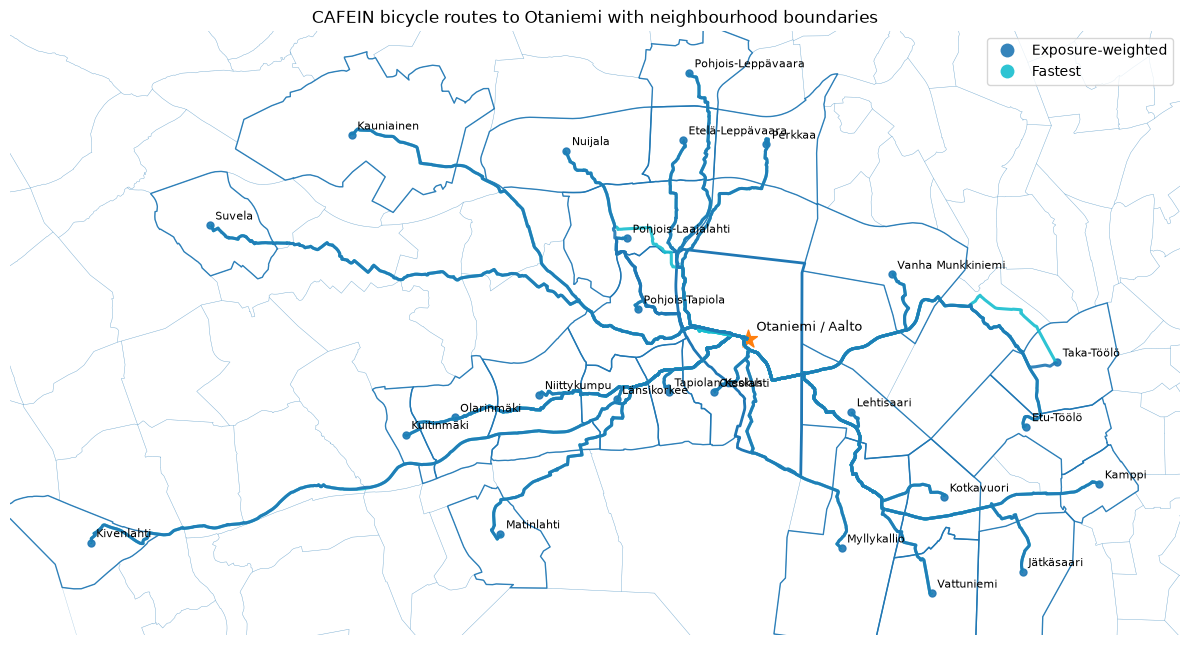

In [36]:
if routes_gdf is not None and len(routes_gdf) > 0:
    # Reproject everything to the neighbourhood CRS so the background polygons
    # and route geometries align cleanly.
    routes_map = routes_gdf.to_crs(units.crs)
    origins_points_map = origins_gdf.loc[
        origins_gdf["origin"].isin(routes_map["origin"].unique())
    ].to_crs(units.crs)
    aalto_map = aalto_destination.to_crs(units.crs)

    # Background: all neighbourhood boundaries for context
    neighbourhood_boundaries = units.copy()

    # Highlight the origin neighbourhoods used in the routed set
    origin_neighbourhoods = units.loc[
        units["Neighbourhood_unit_ID"].astype("Int64").isin(
            pd.Series(routes_map["origin"].unique(), dtype="Int64")
        )
    ].copy()

    # Highlight the destination neighbourhood that contains Otaniemi
    destination_neighbourhood = units.loc[
        units["Neighbourhood_unit_ID"].astype("Int64") == otaniemi_unit_id
    ].copy()

    # Compute a nice zoom extent around the successful routes
    min_x, min_y, max_x, max_y = routes_map.total_bounds
    x_pad = (max_x - min_x) * 0.08
    y_pad = (max_y - min_y) * 0.08

    fig, ax = plt.subplots(figsize=(12, 10))

    # Light context layer
    neighbourhood_boundaries.boundary.plot(
        ax=ax,
        linewidth=0.3,
        alpha=0.35,
    )

    # Highlight origin and destination neighbourhoods
    if len(origin_neighbourhoods) > 0:
        origin_neighbourhoods.boundary.plot(
            ax=ax,
            linewidth=1.0,
            alpha=0.9,
        )

    if len(destination_neighbourhood) > 0:
        destination_neighbourhood.boundary.plot(
            ax=ax,
            linewidth=2.0,
            alpha=1.0,
        )

    # Plot routes with automatic categorical colouring by route choice
    routes_map.plot(
        ax=ax,
        column="route_choice",
        categorical=True,
        legend=True,
        linewidth=2.2,
        alpha=0.9,
    )

    # Plot starting points
    origins_points_map.plot(
        ax=ax,
        marker="o",
        markersize=25,
        alpha=0.9,
    )

    # Annotate origin names so the starts are easier to interpret
    for _, row in origins_points_map.iterrows():
        ax.annotate(
            row["origin_name"],
            xy=(row.geometry.x, row.geometry.y),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )

    # Plot Otaniemi destination
    aalto_map.plot(
        ax=ax,
        marker="*",
        markersize=180,
    )

    dest_x = aalto_map.geometry.iloc[0].x
    dest_y = aalto_map.geometry.iloc[0].y
    ax.annotate(
        "Otaniemi / Aalto",
        xy=(dest_x, dest_y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
    )

    ax.set_xlim(min_x - x_pad, max_x + x_pad)
    ax.set_ylim(min_y - y_pad, max_y + y_pad)
    ax.set_title(
        "CAFEIN bicycle routes to Otaniemi with neighbourhood boundaries"
    )
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print("No successful routes to map.")


## 13. Interpretation

The `status` field is part of the methodology, not just error handling.

If an origin has:

- `ok` for both alternatives: compare fastest vs exposure-weighted;
- `ok` only for fastest: CAFEIN found a normal bicycle route but not an exposure-weighted alternative;
- `no_route`: the origin/destination pair could not be routed with CAFEIN's bicycle network/profile;
- `routing_error`: inspect the stored error message.

These failures are useful when comparing Stage 04 v1 and v2 because OSMnx and CAFEIN can differ in bicycle permissions, network connectivity, snapping, and route search behaviour.
